# HVAC Electircity Demand Analysis and Prediction

## Feature Creation and Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)


In [684]:
df = pd.read_csv("./data/Load_data_01.csv")
df["Time"] = pd.to_datetime(df["Time"])
df["Day_of_Week"] = df["Time"].dt.weekday
df["Is_Workday"] = df["Day_of_Week"] < 5
df["Is_Workday"] = df["Is_Workday"].astype(int)
df.set_index("Time", inplace=True)


In [685]:
df.columns


Index(['air_pressure', 'air_temperature', 'relative_humidity', 'wind_speed',
       'solar_irridiation', 'total_cloud_cover_percent',
       'electricity_demand_values', 'heat_demand_values', 'Day_of_Week',
       'Is_Workday'],
      dtype='object')

In [686]:
df["solar_irridiation_positive"] = df['solar_irridiation'][df['solar_irridiation'] > 0]


solar_irridiation_positive
13    2920
Name: count, dtype: int64

In [746]:
df


,air_pressure,air_temperature,relative_humidity,wind_speed,solar_irridiation,total_cloud_cover_percent,electricity_demand_values,heat_demand_values,Day_of_Week,Is_Workday,solar_irridiation_positive
Time,,,,,,,,,,,
2010-12-01 00:00:00,729.7,25.0,85.0,5.0,0,0.00,289.567557,432.940036,2,1,NaN
2010-12-01 01:00:00,729.4,27.8,77.0,7.0,0,0.00,260.168520,473.935901,2,1,NaN
2010-12-01 02:00:00,728.9,33.3,62.0,7.0,0,0.25,247.273585,483.278761,2,1,NaN
2010-12-01 03:00:00,731.6,32.2,62.0,2.0,0,0.50,257.955878,545.921252,2,1,NaN
2010-12-01 04:00:00,732.6,22.8,96.0,3.0,0,0.25,258.255081,550.526112,2,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2018-11-28 19:00:00,733.3,24.4,60.0,3.0,262,0.00,379.637300,626.192823,2,1,262.0
2018-11-28 20:00:00,733.6,27.8,56.0,4.0,0,0.00,369.976634,609.519358,2,1,NaN
2018-11-28 21:00:00,732.1,38.3,22.0,0.0,0,0.00,365.009491,571.465130,2,1,NaN


## Create daily dataframe

In [688]:
df_daily = pd.DataFrame()


In [689]:
mean_cols = [
    "air_pressure",
    "air_temperature",
    "relative_humidity",
    "wind_speed",
    "total_cloud_cover_percent",
    "solar_irridiation_positive",
]

for _ in mean_cols:
    df_daily[_] = df[_].resample("D").mean()


In [690]:
df_daily["electricity_demand_values"] = (
    df["electricity_demand_values"].resample("D").sum()
)

df_daily["heat_demand_values"] = df["heat_demand_values"].resample("D").sum()
df_daily["heat_demand_mean"] = df["heat_demand_values"].resample("D").mean()
daily_resampled_h = df["heat_demand_values"].resample("D")
df_daily["heat_demand_change"] = daily_resampled_h.max() - daily_resampled_h.min()

df_daily["solar_irridiation_positive_growth_rate"] = (
    df_daily["solar_irridiation_positive"].ffill().pct_change().fillna(0)
)

df_daily["air_temperature_growth_rate"] = (
    df["air_temperature"].resample("D").ffill().pct_change().fillna(0)
)


In [691]:
df_daily.describe().T


/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/pandas/core/nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,count,mean,std,min,25%,50%,75%,max
air_pressure,2920.0,734.587334,3.206897,7.246917e+02,732.450000,734.291667,736.489583,7.474208e+02
air_temperature,2920.0,17.874431,9.032153,-5.070833e+00,10.458333,18.229167,26.155208,3.632500e+01
relative_humidity,2920.0,60.645077,11.590058,2.741667e+01,52.708333,61.104167,68.875000,9.275000e+01
wind_speed,2920.0,4.830608,1.029711,1.958333e+00,4.083333,4.791667,5.500000,9.333333e+00
total_cloud_cover_percent,2920.0,0.323900,0.178468,0.000000e+00,0.191120,0.302083,0.427083,9.791667e-01
solar_irridiation_positive,2920.0,475.002634,31.305920,3.716154e+02,452.961538,475.230769,496.307692,5.825385e+02
electricity_demand_values,2920.0,9453.465406,3230.948896,5.106016e+03,6836.863624,8863.772704,11172.705523,2.540586e+04
electricity_demand_growth_rate,2920.0,0.015616,0.193531,-5.753084e-01,-0.064723,0.000000,0.081494,2.606716e+00
electricity_demand_growth_diff,2919.0,0.707392,1967.037312,-1.128113e+04,-561.301187,0.000000,686.260826,1.330993e+04
electricity_demand_change,2920.0,522.078886,286.560977,2.445560e+02,339.123645,390.051427,633.343973,1.433025e+03


In [692]:
df_daily.replace([np.inf, -np.inf], np.nan, inplace=True)
df_daily.dropna(inplace=True)


In [693]:
df_daily.describe().T


,count,mean,std,min,25%,50%,75%,max
air_pressure,2776.0,734.557880,3.195805,724.691667,732.433333,734.270833,736.444792,746.083333
air_temperature,2776.0,17.932475,9.007711,-5.070833,10.589583,18.356250,26.169792,36.325000
relative_humidity,2776.0,60.698202,11.611562,27.416667,52.781250,61.166667,68.916667,92.750000
wind_speed,2776.0,4.835915,1.031829,1.958333,4.125000,4.791667,5.541667,9.333333
total_cloud_cover_percent,2776.0,0.324305,0.178381,0.000000,0.197917,0.302083,0.427083,0.979167
solar_irridiation_positive,2776.0,475.053951,31.501610,371.615385,452.750000,475.153846,496.634615,582.538462
electricity_demand_values,2776.0,9427.786762,3218.271307,5106.015997,6830.624264,8840.643689,11111.307310,25405.855701
electricity_demand_growth_rate,2776.0,0.020577,0.157058,-0.515504,-0.059760,0.002630,0.083998,1.504137
electricity_demand_growth_diff,2776.0,116.584945,1648.585396,-8697.368562,-503.933607,22.920138,696.697395,8682.745595
electricity_demand_change,2776.0,511.589227,277.910478,244.555984,339.059495,388.472318,566.648699,1394.407914


In [694]:
df_daily["Day_of_Week"] = df_daily.index.day_of_week
df_daily = pd.get_dummies(df_daily, columns=["Day_of_Week"], prefix="Is_Weekday")


In [695]:
weekday_cols = [
    "Is_Weekday_0",
    "Is_Weekday_1",
    "Is_Weekday_2",
    "Is_Weekday_3",
    "Is_Weekday_4",
    "Is_Weekday_5",
    "Is_Weekday_6",
]
for _ in weekday_cols:
    df_daily[_] = df_daily[_].astype(int)
    

In [696]:
df_daily["quarter"] = df_daily.index.quarter
df_daily = pd.get_dummies(df_daily, columns=["quarter"], prefix="Quarter")


In [697]:
qrt_cols = ["Quarter_1", "Quarter_2", "Quarter_3", "Quarter_4"]
for _ in qrt_cols:
    df_daily[_] = df_daily[_].astype(int)


In [698]:
df_daily["month"] = df_daily.index.month
df_daily = pd.get_dummies(df_daily, columns=["month"], prefix="month")


In [699]:
month_cols = [
    "month_1",
    "month_2",
    "month_3",
    "month_4",
    "month_5",
    "month_6",
    "month_7",
    "month_8",
    "month_9",
    "month_10",
    "month_11",
    "month_12",
]
for _ in month_cols:
    df_daily[_] = df_daily[_].astype(int)


### Create relative humidity dummy variables


In [700]:
def label_humidity(humidity):
    if humidity < 30:
        return "Uncomfortable Dry"  # 0
    elif humidity > 60:
        return "Uncomfortable Wet"  # 2
    else:
        return "Comfort"  # 1


In [701]:
df_daily["relative_humidity_label"] = df_daily["relative_humidity"].apply(label_humidity)


In [702]:
df_daily["relative_humidity_label"]


Time
2010-12-02    Uncomfortable Wet
2010-12-03    Uncomfortable Wet
2010-12-04              Comfort
2010-12-05              Comfort
2010-12-06    Uncomfortable Wet
                    ...        
2018-11-24              Comfort
2018-11-25              Comfort
2018-11-26    Uncomfortable Wet
2018-11-27              Comfort
2018-11-28              Comfort
Name: relative_humidity_label, Length: 2776, dtype: object

In [703]:
df_humidity = pd.get_dummies(df_daily["relative_humidity_label"], prefix="huimidity")
for _ in df_humidity.columns:
    df_daily[_] = df_humidity[_].astype(int)


In [704]:
df_daily.drop("relative_humidity_label", axis=1, inplace=True)


In [705]:
df_daily.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2776 entries, 2010-12-02 to 2018-11-28
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   air_pressure                            2776 non-null   float64
 1   air_temperature                         2776 non-null   float64
 2   relative_humidity                       2776 non-null   float64
 3   wind_speed                              2776 non-null   float64
 4   total_cloud_cover_percent               2776 non-null   float64
 5   solar_irridiation_positive              2776 non-null   float64
 6   electricity_demand_values               2776 non-null   float64
 7   electricity_demand_growth_rate          2776 non-null   float64
 8   electricity_demand_growth_diff          2776 non-null   float64
 9   electricity_demand_change               2776 non-null   float64
 10  heat_demand_values                      27

In [747]:
df_daily


,air_pressure,air_temperature,relative_humidity,wind_speed,total_cloud_cover_percent,solar_irridiation_positive,electricity_demand_values,electricity_demand_growth_rate,electricity_demand_growth_diff,electricity_demand_change,...,month_6,month_7,month_8,month_9,month_10,month_11,month_12,huimidity_Comfort,huimidity_Uncomfortable Dry,huimidity_Uncomfortable Wet
Time,,,,,,,,,,,,,,,,,,,,,
2010-12-02,729.583333,28.504167,71.750000,6.625000,0.145833,502.000000,7910.870398,-0.074736,-638.981813,405.577908,...,0,0,0,0,0,0,1,0,0,1
2010-12-03,732.687500,25.712500,71.500000,4.708333,0.187500,441.769231,8758.895028,0.107197,848.024631,400.837767,...,0,0,0,0,0,0,1,0,0,1
2010-12-04,734.087500,26.991667,58.250000,6.416667,0.291667,501.769231,10013.066990,0.143188,1254.171962,456.648291,...,0,0,0,0,0,0,1,1,0,0
2010-12-05,736.916667,25.004167,44.416667,5.708333,0.062500,481.384615,10694.276861,0.068032,681.209870,398.738974,...,0,0,0,0,0,0,1,1,0,0
2010-12-06,730.287500,28.191667,64.875000,4.458333,0.052083,531.076923,9259.911034,-0.134125,-1434.365827,367.792518,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-11-24,734.166667,29.708333,50.208333,5.750000,0.083333,435.076923,11178.246191,-0.084682,-1034.167390,432.748326,...,0,0,0,0,0,1,0,1,0,0
2018-11-25,733.570833,28.379167,59.208333,4.583333,0.239583,512.769231,12096.578195,0.082153,918.332004,389.651357,...,0,0,0,0,0,1,0,1,0,0
2018-11-26,733.987500,26.300000,67.875000,2.666667,0.322917,477.230769,11658.178583,-0.036242,-438.399611,439.018129,...,0,0,0,0,0,1,0,0,0,1


## Training and Testing models

In [706]:
def split_data(data, split_date):
    return data[data.index <= split_date].copy(), data[data.index > split_date].copy()


In [708]:
train, test = split_data(
    df_daily.query("Time >= '2014-01-01' & Time <= '2018-11-20'"), "2017-06-01"
)


In [709]:
X_train, y_train = (
    train.drop(["electricity_demand_values"], axis=1),
    train["electricity_demand_values"],
)


X_test, y_test = (
    test.drop(["electricity_demand_values"], axis=1),
    test["electricity_demand_values"],
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((1181, 41), (1181,), (507, 41), (507,))

In [710]:
RF_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)


In [711]:
RF_reg.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [712]:
y_pred = RF_reg.predict(X_test)


In [713]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")


RMSE: 1148.7417577759916
R^2 Score: 0.88691647758852


In [714]:
df_results = pd.DataFrame({"Time": y_test.index, "y_test": y_test, "y_pred": y_pred})


<Axes: xlabel='Time'>

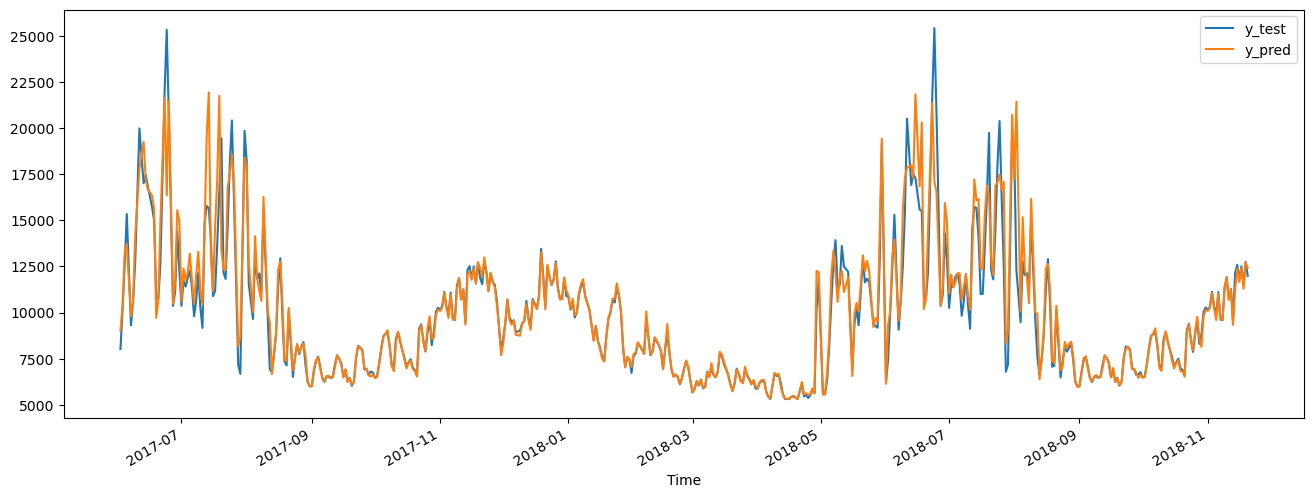

In [715]:
df_results.plot(x="Time", figsize=(16, 6))


In [716]:
from sklearn.model_selection import TimeSeriesSplit, KFold


In [717]:
# X = df_daily.drop(["electricity_demand_values"], axis=1)
# y = df_daily["electricity_demand_values"]
# df_daily.query("Time >= '2014-01-01' & Time <= '2018-11-20'")


In [718]:
df_daily.columns


Index(['air_pressure', 'air_temperature', 'relative_humidity', 'wind_speed',
       'total_cloud_cover_percent', 'solar_irridiation_positive',
       'electricity_demand_values', 'electricity_demand_growth_rate',
       'electricity_demand_growth_diff', 'electricity_demand_change',
       'heat_demand_values', 'heat_demand_mean', 'heat_demand_change',
       'heat_demand_growth_rate', 'solar_irridiation_positive_growth_rate',
       'air_temperature_growth_rate', 'Is_Weekday_0', 'Is_Weekday_1',
       'Is_Weekday_2', 'Is_Weekday_3', 'Is_Weekday_4', 'Is_Weekday_5',
       'Is_Weekday_6', 'Quarter_1', 'Quarter_2', 'Quarter_3', 'Quarter_4',
       'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
       'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12',
       'huimidity_Comfort', 'huimidity_Uncomfortable Dry',
       'huimidity_Uncomfortable Wet'],
      dtype='object')

In [719]:
features = [
    "air_pressure",
    "air_temperature",
    "relative_humidity",
    "wind_speed",
    "total_cloud_cover_percent",
    "solar_irridiation_positive",
    "electricity_demand_growth_rate",
    "electricity_demand_growth_diff",
    "electricity_demand_change",
    "heat_demand_values",
    "heat_demand_mean",
    "heat_demand_change",
    "heat_demand_growth_rate",
    "solar_irridiation_positive_growth_rate",
    "air_temperature_growth_rate",
    "Is_Weekday_0",
    "Is_Weekday_1",
    "Is_Weekday_2",
    "Is_Weekday_3",
    "Is_Weekday_4",
    "Is_Weekday_5",
    "Is_Weekday_6",
    "Quarter_1",
    "Quarter_2",
    "Quarter_3",
    "Quarter_4",
    "month_1",
    "month_2",
    "month_3",
    "month_4",
    "month_5",
    "month_6",
    "month_7",
    "month_8",
    "month_9",
    "month_10",
    "month_11",
    "month_12",
    "huimidity_Comfort",
    "huimidity_Uncomfortable Dry",
    "huimidity_Uncomfortable Wet",
]


In [720]:
train_daily = df_daily.query("Time <= '2016-01-01'") # X_train
test_daily = df_daily.query("Time > '2016-01-01'") # X_test


In [721]:
RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=5, random_state=42, n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_ls = []
rmse_ls = []

for train_index, val_index in kf.split(train_daily):
    X_train, X_val = (
        train_daily.iloc[train_index][features],
        train_daily.iloc[val_index][features],
    )
    y_train, y_val = (
        train_daily["electricity_demand_values"].iloc[train_index],
        train_daily["electricity_demand_values"].iloc[val_index],
    )
    RF_reg.fit(X_train, y_train)
    y_val_pred = RF_reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    rmse_ls.append(rmse)
    r2_lst.append(r2)
    print(f"RMSE: {rmse}")
    print(f"R^2 Score: {r2}")


RMSE: 740.7528332119468
R^2 Score: 0.9511894630562038
RMSE: 650.4592933390257
R^2 Score: 0.9507937019270781
RMSE: 902.8411908318911
R^2 Score: 0.9258747213723738
RMSE: 751.4068497143608
R^2 Score: 0.9384393304608822
RMSE: 774.670919139387
R^2 Score: 0.9461865017922311


In [722]:
from sklearn.linear_model import LinearRegression


In [723]:
X_train, y_train = (
    train.drop(["electricity_demand_values"], axis=1),
    train["electricity_demand_values"],
)


X_test, y_test = (
    test.drop(["electricity_demand_values"], axis=1),
    test["electricity_demand_values"],
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((1181, 41), (1181,), (507, 41), (507,))

In [724]:
Lin_Reg = LinearRegression()
Lin_Reg.fit(X_train, y_train)


LinearRegression()

In [725]:
y_pred = Lin_Reg.predict(X_test)


In [726]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")


RMSE: 1221.1969112833133
R^2 Score: 0.8722014561500698


In [727]:
df_results = pd.DataFrame({"Time": y_test.index, "y_test": y_test, "y_pred": y_pred})


<Axes: xlabel='Time'>

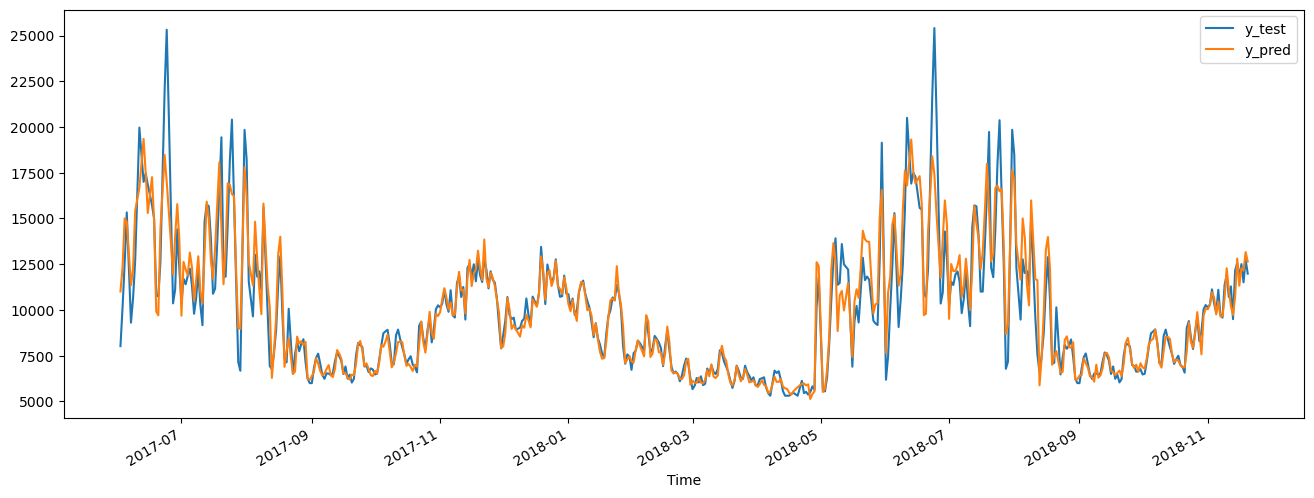

In [728]:
df_results.plot(x="Time", figsize=(16, 6))


In [741]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_ls = []
rmse_ls = []

for train_index, val_index in kf.split(train_daily):
    X_train, X_val = (
        train_daily.iloc[train_index][features],
        train_daily.iloc[val_index][features],
    )
    y_train, y_val = (
        train_daily["electricity_demand_values"].iloc[train_index],
        train_daily["electricity_demand_values"].iloc[val_index],
    )
    Lin_Reg.fit(X_train, y_train)
    y_val_pred = Lin_Reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    rmse_ls.append(rmse)
    r2_lst.append(r2)
    print(f"RMSE: {rmse}")
    print(f"R^2 Score: {r2}")


RMSE: 1023.654734884848
R^2 Score: 0.9067875459769248
RMSE: 985.4304739313402
R^2 Score: 0.8870639941852088
RMSE: 1151.9777570264682
R^2 Score: 0.879320974042985
RMSE: 986.4250045098122
R^2 Score: 0.8939083557882328
RMSE: 1112.094510337874
R^2 Score: 0.8890978124764819


In [730]:
import xgboost as xgb


In [731]:
xgb_reg = xgb.XGBRegressor(n_estimators=1000)


In [732]:
xgb_reg.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    early_stopping_rounds=50,  # stop if 50 consequent rounds without decrease of error
    verbose=False,
)  # Change verbose to True if you want to see it train


/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/xgboost/data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/xgboost/data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/xgboost/data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/xgboost/data.py:336: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=1000, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, ...)

In [733]:
y_pred = xgb_reg.predict(X_test)


/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/xgboost/data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/xgboost/data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/xgboost/data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/xgboost/data.py:336: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
 

In [734]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")


RMSE: 79.57175082103947
R^2 Score: 0.9994630779044423


In [735]:
import lightgbm as lgb


In [736]:
train_data = lgb.Dataset(X_train, label=y_train)


In [737]:
params = {
    "objective": "regression",
    "metric": "mse",
    "boosting_type": "gbdt",
    "num_leaves": 100,
    "learning_rate": 0.05,
    "feature_fraction": 0.9,
}

n = 100


In [738]:
lgb_reg = lgb.train(params, train_data, n)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4061
[LightGBM] [Info] Number of data points in the train set: 1478, number of used features: 42
[LightGBM] [Info] Start training from score 9415.813781
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

In [739]:
y_pred = lgb_reg.predict(X_test)


In [740]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")


RMSE: 241.19157990859583
R^2 Score: 0.9950669248299122
